# Финальный проект. Этап 1 — Загрузка и очистка данных

**Проект:** анализ CRM-данных онлайн-школы программирования X.
**Цель этапа:** загрузить исходные данные, выполнить очистку и сохранить чистые датасеты в `data_clean/`.

**Принципы:**
- Исходные файлы в `data/` не изменяются — работаем с копией в памяти.
- Каждое решение по очистке обосновано (правила заказчика из FAQ — см. `TASK.md`).
- Результат: 4 чистых CSV + таблица «было/стало».

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (10, 5)

DATA = Path('../data')
OUT = Path('../data_clean')
OUT.mkdir(exist_ok=True)

## 1. Загрузка данных

Важный момент: колонки с идентификаторами (`Id`, `Contact Name`, `CONTACTID`) — это 19-значные числа.
Если читать их как числа, pandas превратит их в `float64` и **потеряет точность** (появятся ложные дубликаты).
Поэтому все Id читаем как строки (`dtype=str`).

In [2]:
deals = pd.read_excel(DATA / 'Deals (Done).xlsx', dtype={'Id': str, 'Contact Name': str})
calls = pd.read_excel(DATA / 'Calls (Done).xlsx', dtype={'Id': str, 'CONTACTID': str})
contacts = pd.read_excel(DATA / 'Contacts (Done).xlsx', dtype={'Id': str})
spend = pd.read_excel(DATA / 'Spend (Done).xlsx')

# запомним исходные размеры для итоговой таблицы "было/стало"
rows_before = {'deals': len(deals), 'calls': len(calls), 'contacts': len(contacts), 'spend': len(spend)}

for name, df in [('Deals', deals), ('Calls', calls), ('Contacts', contacts), ('Spend', spend)]:
    print(f'{name}: {df.shape[0]} строк, {df.shape[1]} колонок')

Deals: 21595 строк, 23 колонок
Calls: 95874 строк, 11 колонок
Contacts: 18548 строк, 4 колонок
Spend: 20779 строк, 8 колонок


In [3]:
deals.head(3)

,Id,Deal Owner Name,Closing Date,Quality,Stage,Lost Reason,Page,Campaign,SLA,Content,Term,Source,Payment Type,Product,Education Type,Created Time,Course duration,Months of study,Initial Amount Paid,Offer Total Amount,Contact Name,City,Level of Deutsch
0,5805028000056864695,Ben Hall,NaN,NaN,New Lead,NaN,/eng/test,03.07.23women,NaN,v16,women,Facebook Ads,NaN,NaN,NaN,21.06.2024 15:30,NaN,NaN,NaN,NaN,5805028000056849495,NaN,NaN
1,5805028000056859489,Ulysses Adams,NaN,NaN,New Lead,NaN,/at-eng,NaN,NaN,NaN,NaN,Organic,NaN,Web Developer,Morning,21.06.2024 15:23,6.0,NaN,0,2000,5805028000056834471,NaN,NaN
2,5805028000056832357,Ulysses Adams,21.06.2024,D - Non Target,Lost,Non target,/at-eng,engwien_AT,00:26:43,b1-at,21_06_2024,Telegram posts,NaN,NaN,NaN,21.06.2024 14:45,NaN,NaN,NaN,NaN,5805028000056854421,NaN,NaN


## 2. Обзор пропусков

Смотрим долю пропусков в Deals — это главная таблица. Важно понять, какие пропуски являются **ошибками**,
а какие — **структурной особенностью воронки** (поля Product, Payment Type и т.п. заполняются только
на поздних стадиях сделки, поэтому пропуски там — норма, удалять такие строки нельзя).

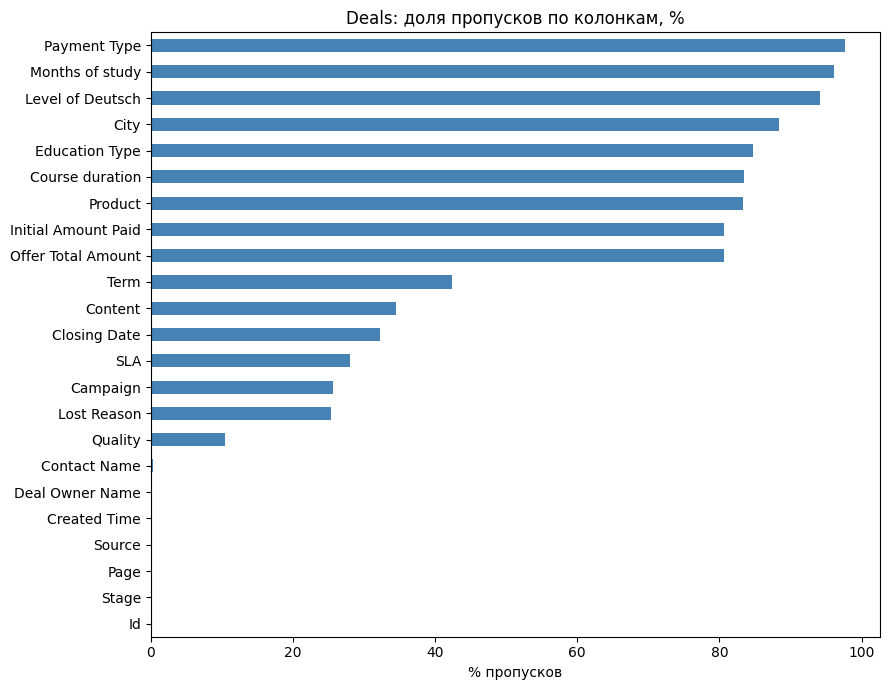

In [4]:
missing = (deals.isna().mean() * 100).sort_values()
ax = missing.plot.barh(figsize=(9, 7), color='steelblue')
ax.set_title('Deals: доля пропусков по колонкам, %')
ax.set_xlabel('% пропусков')
plt.tight_layout()
plt.show()

## 3. Очистка Contacts

Самая чистая таблица: пропусков нет, дубликатов по Id нет. Осталось привести даты к типу `datetime`
(в файле они хранятся строками вида `27.06.2023 11:28`).

In [5]:
print('Дубликатов по Id:', contacts['Id'].duplicated().sum())
print('Пропусков всего:', contacts.isna().sum().sum())

for col in ['Created Time', 'Modified Time']:
    contacts[col] = pd.to_datetime(contacts[col], format='%d.%m.%Y %H:%M')

contacts.dtypes

Дубликатов по Id: 0
Пропусков всего: 0


Id                            object
Contact Owner Name            object
Created Time          datetime64[ns]
Modified Time         datetime64[ns]
dtype: object

## 4. Очистка Calls

Проблемы и решения:
1. `Dialled Number` и `Tag` пустые на 100% → удаляем как неактуальные столбцы (требование задания: «удалите неактуальные столбцы»).
2. `Call Start Time` — строка → `datetime`.
3. `Scheduled in CRM` — числовой флаг 0/1, пропуски у входящих/пропущенных звонков (там поле неприменимо) — оставляем как есть.
4. Дубликатов по Id нет (проверяем).

In [6]:
print('Пропусков в Dialled Number: {} из {}'.format(calls['Dialled Number'].isna().sum(), len(calls)))
print('Пропусков в Tag: {} из {}'.format(calls['Tag'].isna().sum(), len(calls)))
print('Дубликатов по Id:', calls['Id'].duplicated().sum())

calls = calls.drop(columns=['Dialled Number', 'Tag'])
calls['Call Start Time'] = pd.to_datetime(calls['Call Start Time'], format='%d.%m.%Y %H:%M')
calls['Call Duration (in seconds)'] = pd.to_numeric(calls['Call Duration (in seconds)'], errors='coerce')

calls.dtypes

Пропусков в Dialled Number: 95874 из 95874
Пропусков в Tag: 95874 из 95874
Дубликатов по Id: 0


Id                                    object
Call Start Time               datetime64[ns]
Call Owner Name                       object
CONTACTID                             object
Call Type                             object
Call Duration (in seconds)           float64
Call Status                           object
Outgoing Call Status                  object
Scheduled in CRM                     float64
dtype: object

## 5. Очистка Spend

В таблице 917 полных дубликатов строк. Прежде чем удалять — проверяем, что в лишних копиях нет денег
(иначе можно случайно удалить реальные расходы). Проверка показывает: **все дублирующиеся копии нулевые**
(Spend = 0, в основном строки Bloggers без кампании), поэтому удаление безопасно и не искажает суммы.

In [7]:
dups_extra = spend[spend.duplicated()]
print('Лишних копий-дубликатов:', len(dups_extra))
print('Сумма Spend в лишних копиях:', dups_extra['Spend'].sum())
print('Сумма Impressions в лишних копиях:', dups_extra['Impressions'].sum())
print('Сумма Clicks в лишних копиях:', dups_extra['Clicks'].sum())

spend_total_before = spend['Spend'].sum()
spend = spend.drop_duplicates().reset_index(drop=True)
print('\nБыло строк: {}, стало: {}'.format(rows_before['spend'], len(spend)))
print('Контроль: сумма Spend не изменилась:', spend['Spend'].sum() == spend_total_before)

Лишних копий-дубликатов: 917
Сумма Spend в лишних копиях: 0.0
Сумма Impressions в лишних копиях: 0
Сумма Clicks в лишних копиях: 46

Было строк: 20779, стало: 19862
Контроль: сумма Spend не изменилась: True


Пропуски в `Campaign` / `AdGroup` / `Ad` — норма для каналов без рекламных кампаний (Organic, SMM,
Webinar и т.п.), их не трогаем. `Date` уже `datetime`. Типы числовых колонок корректны.

In [8]:
print(spend.isna().sum())
spend.dtypes

Date              0
Source            0
Campaign       5077
Impressions       0
Spend             0
Clicks            0
AdGroup        5911
Ad             5911
dtype: int64


Date           datetime64[ns]
Source                 object
Campaign               object
Impressions             int64
Spend                 float64
Clicks                  int64
AdGroup                object
Ad                     object
dtype: object

## 6. Очистка Deals (главная таблица)

### 6.1 Битые строки
Есть 2 строки без Id (одна полностью пустая, во второй заполнено одно поле) — это мусор выгрузки, удаляем.
Полных дубликатов строк при корректном чтении Id нет (проверяем).

In [9]:
print('Строк без Id:', deals['Id'].isna().sum())
print('Полных дубликатов:', deals.duplicated().sum())
print('Дубликатов по Id (без учёта пустых):', deals.dropna(subset=['Id'])['Id'].duplicated().sum())

deals = deals.dropna(subset=['Id']).reset_index(drop=True)
print('Стало строк:', len(deals))

Строк без Id: 2
Полных дубликатов: 0
Дубликатов по Id (без учёта пустых): 0
Стало строк: 21593


### 6.2 Даты и SLA

- `Created Time` — строка `дд.мм.гггг чч:мм` → `datetime`.
- `Closing Date` — строка `дд.мм.гггг` → `datetime`.
- `SLA` — время ответа менеджера на заявку. Excel хранит его неоднородно: и как время (`чч:мм:сс`),
  и как интервал (`timedelta`, если ответ занял больше суток) → приводим всё к **секундам**.

In [10]:
import datetime as dt

deals['Created Time'] = pd.to_datetime(deals['Created Time'], format='%d.%m.%Y %H:%M')
deals['Closing Date'] = pd.to_datetime(deals['Closing Date'], dayfirst=True)

def sla_to_seconds(v):
    """datetime.time / timedelta / строка 'чч:мм:сс' -> секунды; пропуски остаются NaN"""
    if pd.isna(v):
        return np.nan
    if isinstance(v, dt.timedelta):
        return v.total_seconds()
    if isinstance(v, dt.time):
        return v.hour * 3600 + v.minute * 60 + v.second
    try:
        h, m, s = map(int, str(v).split(':'))
        return h * 3600 + m * 60 + s
    except ValueError:
        return np.nan

deals['SLA (seconds)'] = deals['SLA'].apply(sla_to_seconds)
deals = deals.drop(columns=['SLA'])

deals[['Created Time', 'Closing Date', 'SLA (seconds)']].agg(['min', 'max'])

,Created Time,Closing Date,SLA (seconds)
min,2023-07-03 17:03:00,2022-10-11,3.0
max,2024-06-21 15:30:00,2024-12-11,26908464.0


### 6.3 Денежные колонки

`Initial Amount Paid` и `Offer Total Amount` почти все числовые, но встречаются значения
в европейском формате с символом валюты: `€ 3.500,00` (точка — разделитель тысяч, запятая — десятичный).
Пишем парсер и приводим обе колонки к числу.

Также по FAQ заказчика значения **0, 1, 9 — демо-доступы за символическую плату**. Это не ошибка,
но при анализе среднего чека их нужно отличать от полноценных оплат — добавляем флаг `Is Demo`.

In [11]:
def parse_money(v):
    """'€ 3.500,00' -> 3500.0; числа возвращаем как есть"""
    if pd.isna(v):
        return np.nan
    if isinstance(v, (int, float)):
        return float(v)
    s = str(v).replace('€', '').replace(' ', '')
    s = s.replace('.', '').replace(',', '.')  # 3.500,00 -> 3500.00
    try:
        return float(s)
    except ValueError:
        return np.nan

for col in ['Initial Amount Paid', 'Offer Total Amount']:
    deals[col] = deals[col].apply(parse_money)

deals['Is Demo'] = deals['Initial Amount Paid'].isin([0, 1, 9])
print('Демо-сделок:', deals['Is Demo'].sum())
deals[['Initial Amount Paid', 'Offer Total Amount']].describe().round(1)

Демо-сделок: 880


,Initial Amount Paid,Offer Total Amount
count,4165.0,4185.0
mean,950.1,7128.7
std,1422.2,4636.0
min,0.0,0.0
25%,300.0,3000.0
50%,1000.0,11000.0
75%,1000.0,11000.0
max,11500.0,11500.0


### 6.4 Аномалия: дата закрытия раньше даты создания

По FAQ заказчика это **очевидная ошибка**, способ исправления — на усмотрение аналитика.

**Наше решение:** дату закрытия в таких строках считаем недостоверной → заменяем на `NaT`
и помечаем флагом `Closing Date Error`. Так эти строки не исказят анализ длительности сделок,
но сами сделки (их стадия, суммы, источник) остаются в данных.

In [12]:
bad_close = deals['Closing Date'].dt.date < deals['Created Time'].dt.date
print('Строк с Closing Date < Created Time:', bad_close.sum())
print('\nИх стадии:')
print(deals.loc[bad_close, 'Stage'].value_counts())

deals['Closing Date Error'] = bad_close
deals.loc[bad_close, 'Closing Date'] = pd.NaT

Строк с Closing Date < Created Time: 44

Их стадии:
Stage
Lost            40
Payment Done     4
Name: count, dtype: int64


### 6.5 Аномалия: первый платёж больше суммы предложения

`Initial Amount Paid > Offer Total Amount` — по FAQ тоже очевидная ошибка ручного ввода.

**Наше решение:** первый платёж (IAP) — это фактически полученные деньги, ему доверяем больше.
`Offer Total Amount` в таких строках считаем недостоверным → `NaN`, строки помечаем флагом `Amount Error`.

In [13]:
amount_err = deals['Initial Amount Paid'] > deals['Offer Total Amount']
print('Строк с IAP > OTA:', amount_err.sum())

deals['Amount Error'] = amount_err.fillna(False)
deals.loc[deals['Amount Error'], 'Offer Total Amount'] = np.nan

Строк с IAP > OTA: 58


### 6.6 Уровень немецкого языка

`Level of Deutsch` заполнялся менеджерами вручную в свободной форме: «б1 (ждет серт)», «А2 ( Б1 март )»,
«25 лет живет в Германии», встречаются даже адреса. Уникальных значений — сотни.

**Наше решение:** извлекаем регулярным выражением **первый упомянутый уровень** по шкале A0–C2
(кириллица А/Б/В/С приводится к латинице, регистр не важен). Записи «нет», «не учил», «никакой»,
«нулевой» считаем уровнем `A0`. Всё, из чего уровень извлечь нельзя, — `NaN`.
Это огрубление (например, «ждёт результата B1» засчитается как B1), но единая шкала важнее
точности единичных записей — и это решение легко объяснить заказчику.

In [14]:
def extract_deutsch_level(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip().lower()
    # явное отсутствие языка
    if re.search(r'нет|не учил|никак|нулев|ня-0|ня - 0', s):
        return 'A0'
    # кириллица -> латиница (б и в обе означают B: "б1" фонетически, "в1" визуально)
    s = s.translate(str.maketrans({'а': 'a', 'б': 'b', 'в': 'b', 'с': 'c'}))
    m = re.search(r'([abc])\s*([0-2])', s)
    if m:
        letter, digit = m.group(1).upper(), m.group(2)
        if letter + digit in ('A0', 'A1', 'A2', 'B1', 'B2', 'C1', 'C2'):
            return letter + digit
    return np.nan

deals['Deutsch Level'] = deals['Level of Deutsch'].apply(extract_deutsch_level)

print('Заполнено до очистки:', deals['Level of Deutsch'].notna().sum())
print('Извлечено уровней:   ', deals['Deutsch Level'].notna().sum())
print()
print(deals['Deutsch Level'].value_counts().sort_index())

Заполнено до очистки: 1251
Извлечено уровней:    1204

Deutsch Level
A0     17
A1     25
A2    149
B1    814
B2    170
C1     26
C2      3
Name: count, dtype: int64


### 6.7 Категориальные колонки: City, Education Type, Quality

- `City`: значение «-» — это отсутствие данных → `NaN`; убираем лишние пробелы. (Глубокую унификацию
  городов — адреса вместо города и т.п. — сделаем точечно в географическом анализе.)
- `Education Type`: значение `#REF!` — ошибка экспорта из электронных таблиц → `NaN`.
- `Quality`: значения A–E — шкала качества лида; «F» (3 строки, все Lost) в шкале заказчика
  не описана → считаем мусорным значением, `NaN`.

In [15]:
deals['City'] = deals['City'].astype('string').str.strip().replace({'-': pd.NA, '': pd.NA})
deals['Education Type'] = deals['Education Type'].replace('#REF!', np.nan)
deals['Quality'] = deals['Quality'].replace('F', np.nan)

print('City заполнено:', deals['City'].notna().sum())
print(deals['Education Type'].value_counts(dropna=False).head())
print()
print(deals['Quality'].value_counts(dropna=False))

City заполнено: 2163
Education Type
NaN        18294
Morning     2895
Evening      404
Name: count, dtype: int64

Quality
E - Non Qualified    7634
D - Non Target       6248
C - Low              3459
NaN                  2256
B - Medium           1564
A - High              432
Name: count, dtype: int64


### 6.8 Числовые колонки длительности обучения

In [16]:
deals['Course duration'] = pd.to_numeric(deals['Course duration'], errors='coerce')
deals['Months of study'] = pd.to_numeric(deals['Months of study'], errors='coerce')
deals[['Course duration', 'Months of study']].describe().round(2)

,Course duration,Months of study
count,3587.00,840.00
mean,10.20,5.44
std,1.83,2.92
min,6.00,0.00
25%,11.00,3.00
50%,11.00,5.00
75%,11.00,8.00
max,11.00,11.00


## 7. Итоги очистки и сохранение

Собираем таблицу «было/стало» и сохраняем чистые датасеты в `data_clean/`.
Id сохраняем строками — при последующей загрузке тоже читать с `dtype=str`!

In [17]:
summary = pd.DataFrame({
    'Строк было': rows_before,
    'Строк стало': {'deals': len(deals), 'calls': len(calls), 'contacts': len(contacts), 'spend': len(spend)},
})
summary['Удалено строк'] = summary['Строк было'] - summary['Строк стало']
summary['Что сделано'] = [
    'удалены 2 битые строки; даты; SLA->сек; суммы из €-формата; флаги Demo/ошибок; нормализация Deutsch/City/Quality/EduType',
    'удалены пустые колонки Dialled Number и Tag; даты',
    'даты',
    'удалено 917 нулевых дубликатов',
]
summary

,Строк было,Строк стало,Удалено строк,Что сделано
deals,21595,21593,2,удалены 2 битые строки; даты; SLA->сек; суммы ...
calls,95874,95874,0,удалены пустые колонки Dialled Number и Tag; даты
contacts,18548,18548,0,даты
spend,20779,19862,917,удалено 917 нулевых дубликатов


In [18]:
deals.to_csv(OUT / 'deals_clean.csv', index=False)
calls.to_csv(OUT / 'calls_clean.csv', index=False)
contacts.to_csv(OUT / 'contacts_clean.csv', index=False)
spend.to_csv(OUT / 'spend_clean.csv', index=False)

for f in sorted(OUT.glob('*.csv')):
    print(f.name, '-', round(f.stat().st_size / 1024 / 1024, 2), 'МБ')

calls_clean.csv - 10.58 МБ
contacts_clean.csv - 1.31 МБ
deals_clean.csv - 4.31 МБ
spend_clean.csv - 1.23 МБ


## Выводы этапа

1. **Id только строками** — иначе float теряет точность 19-значных идентификаторов и появляются ложные дубликаты.
2. **Calls**: удалены 2 полностью пустые колонки; даты приведены к `datetime`.
3. **Spend**: удалено 917 дубликатов — все копии нулевые, суммы расходов не изменились (проверено).
4. **Deals**: удалены 2 битые строки; даты и суммы приведены к корректным типам (включая парсинг
   €-формата); аномалии (закрытие раньше создания — 44, платёж больше предложения — 55) помечены
   флагами и нейтрализованы по правилам FAQ заказчика; свободный текст уровня немецкого приведён
   к шкале A0–C2; категории очищены от мусора («-», `#REF!`, «F»).
5. **Демо-доступы** (оплаты 0/1/9) помечены флагом `Is Demo` — пригодится при расчёте среднего чека.
6. Чистые данные сохранены в `data_clean/` — дальше работаем только с ними.